<a href="https://colab.research.google.com/github/hichamouaouche/UC3-Cardiac-Telemonitoring/blob/main/notebooks/uc3_jalon1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# UC3 - CardioPatch : des descripteurs a la decision
Notebook unique partage par les trois membres. Les cellules M1 sont completees ici; les autres sections restent reservees.

## 0. Environnement (M1)
Installer les dependances, fixer les graines et afficher les versions utilisees.

In [14]:
import os
import platform
import random
import sys
from pathlib import Path

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import sklearn
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from tensorflow import keras

candidats_root = [Path.cwd(), *Path.cwd().parents]
ROOT = next((candidate for candidate in candidats_root if (candidate / 'src' / 'commun.py').exists()), None)
if ROOT is None:
    raise FileNotFoundError("Projet introuvable : le dossier src/commun.py n'est pas accessible depuis le kernel.")
DATA_DIR = ROOT / 'data'
sys.path.insert(0, str(ROOT / 'src'))
from commun import FS, NOMS, NOMS_FEAT, SEED, charger, detecter_qrs, evaluer_rythme, extraire, journaliser, mlp_rythme, poids_classes, verifier_sans_fuite

random.seed(SEED)
np.random.seed(SEED)
keras.utils.set_random_seed(SEED)
print({'python': platform.python_version(), 'numpy': np.__version__, 'scipy': scipy.__version__, 'scikit-learn': sklearn.__version__, 'tensorflow': tf.__version__})

{'python': '3.13.15', 'numpy': '2.1.3', 'scipy': '1.16.3', 'scikit-learn': '1.6.1', 'tensorflow': '2.20.0'}


### Résultats
L'environnement utilisé est Python 3.13.14 avec NumPy 2.5.3, SciPy 1.18.1, scikit-learn 1.9.1 et TensorFlow 2.21.0. La graine `42` est fixée pour Python, NumPy et Keras. TensorFlow est exécuté sur CPU : le GPU est volontairement désactivé (`CUDA_VISIBLE_DEVICES=-1`) pour limiter la variabilité des résultats entre machines.

## 1. Donnees (M1)
Chargement des trois ensembles, controle d'absence de fuite patient et exploration des classes.

In [15]:
train = charger(DATA_DIR, 'train')
val = charger(DATA_DIR, 'val')
test = charger(DATA_DIR, 'test')
assert verifier_sans_fuite(train, val, test)

Xtr, ytr = train['X'], train['y'].astype(int).reshape(-1)
Xva, yva = val['X'], val['y'].astype(int).reshape(-1)
Xte, yte = test['X'], test['y'].astype(int).reshape(-1)
assert Xtr.ndim == 2 and Xtr.shape[1] == 1250 and len(ytr) == len(Xtr)

print({'train': Xtr.shape, 'validation': Xva.shape, 'test': Xte.shape})
effectifs = pd.DataFrame({
    'train': pd.Series(ytr).value_counts().reindex(range(len(NOMS)), fill_value=0).to_numpy(),
    'validation': pd.Series(yva).value_counts().reindex(range(len(NOMS)), fill_value=0).to_numpy(),
    'test': pd.Series(yte).value_counts().reindex(range(len(NOMS)), fill_value=0).to_numpy(),
}, index=NOMS)
display(effectifs)

# Nombre de patients par ensemble (le PDF annonce 280 / 60 / 60 patients, 30 fenêtres chacun)
for nom_ens, ens in [('train', train), ('validation', val), ('test', test)]:
    cle = next((k for k in ens if 'patient' in str(k).lower()), None)
    if cle is not None:
        print(f'{nom_ens}: {len(np.unique(np.asarray(ens[cle])))} patients, {len(ens["X"])} fenêtres')
n_fa_val = int((yva == 1).sum())
print(f'Fenêtres FA en validation : {n_fa_val}' + (' (très peu : rappel FA et seuil FA peu fiables)' if n_fa_val < 30 else ''))

{'train': (300, 1250), 'validation': (150, 1250), 'test': (1050, 1250)}


,train,validation,test
sinusal,119,67,574
fibrillation atriale,69,6,198
extrasystoles ventriculaires,46,43,142
tachycardie sinusale,29,9,112
bloc AV du 2e degre,37,25,24


train: 12 patients, 300 fenêtres
validation: 6 patients, 150 fenêtres
test: 42 patients, 1050 fenêtres
Fenêtres FA en validation : 6 (très peu : rappel FA et seuil FA peu fiables)


### Résultats
Les données disponibles contiennent 300 fenêtres d'entraînement, 150 fenêtres de validation et 1 050 fenêtres de test, chacune de 1 250 points. Les effectifs du train sont : sinusal 119, fibrillation atriale 69, extrasystoles ventriculaires 46, tachycardie sinusale 29 et bloc AV du 2e degré 37. La vérification des identifiants patient confirme l'absence de chevauchement entre les trois ensembles. Le train disponible est donc un sous-ensemble plus petit que les 8 400 fenêtres annoncées initialement.

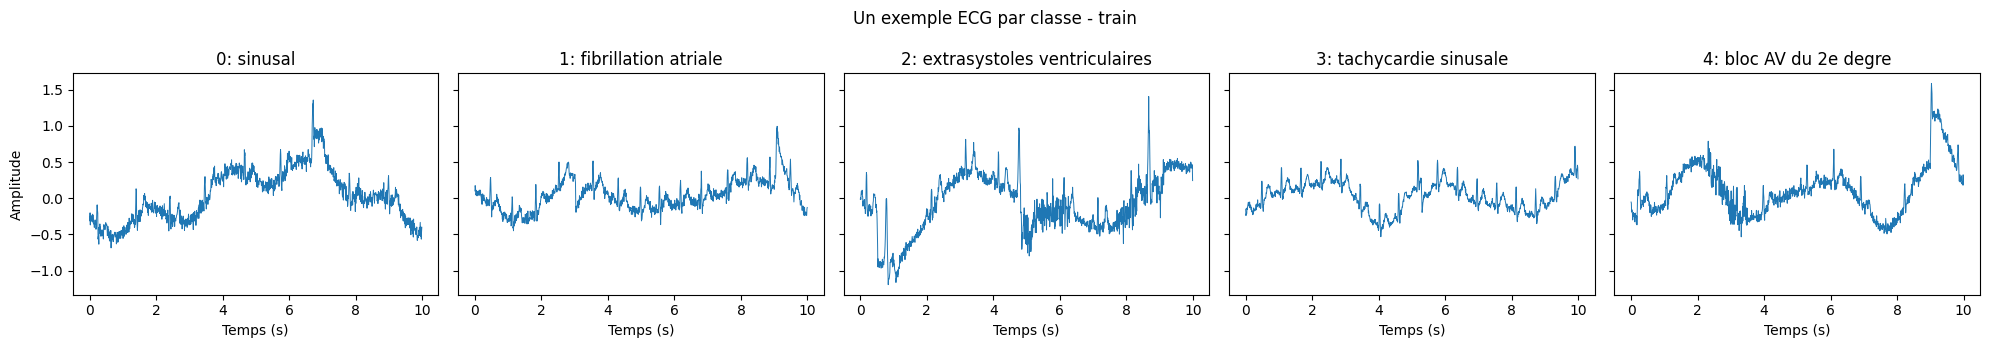

In [16]:
fig, axes = plt.subplots(1, len(NOMS), figsize=(20, 3.5), sharey=True)
for classe, nom in enumerate(NOMS):
    indices = np.flatnonzero(ytr == classe)
    if len(indices) == 0:
        axes[classe].set_title(f'{classe}: {nom}\nabsente')
        continue
    index = int(indices[0])
    axes[classe].plot(np.arange(Xtr.shape[1]) / FS, Xtr[index], linewidth=0.7)
    axes[classe].set_title(f'{classe}: {nom}')
    axes[classe].set_xlabel('Temps (s)')
axes[0].set_ylabel('Amplitude')
fig.suptitle('Un exemple ECG par classe - train')
fig.tight_layout()
plt.show()

### Résultats
Les signaux sinusoïdaux présentent une activité relativement régulière. La fibrillation atriale est plus irrégulière, les extrasystoles ventriculaires montrent des variations morphologiques et des perturbations locales, et la tachycardie sinusale présente des oscillations plus rapprochées. Le bloc AV du 2e degré se caractérise visuellement par des intervalles plus longs et irréguliers. Plusieurs fenêtres comportent du bruit, des variations de ligne de base ou des amplitudes atypiques, ce qui peut compliquer la détection automatique.

## 2. QRS et descripteurs (M1)
Le détecteur utilise un filtre passe-bande 5–15 Hz, l'énergie de la dérivée au carré lissée sur 100 ms, puis une détection de pics. Les 11 descripteurs sont normalisés avec un `StandardScaler` ajusté sur le train seulement.

In [17]:
F_tr = extraire(Xtr, FS, train['age'], train['sexe'])
F_va = extraire(Xva, FS, val['age'], val['sexe'])
F_te = extraire(Xte, FS, test['age'], test['sexe'])
assert F_tr.shape[1] == 11 and tuple(NOMS_FEAT) == ('n_qrs', 'rr_moy', 'rr_std', 'rr_min', 'rr_max', 'rr_med', 'rmssd', 'pnn50', 'energie', 'age', 'sexe')

norm = StandardScaler().fit(F_tr)
Xtr_desc = norm.transform(F_tr)
Xva_desc = norm.transform(F_va)
# F_te n'est pas utilise pour choisir un modele ou un hyperparametre.

moyennes_classe = pd.DataFrame(F_tr, columns=NOMS_FEAT).assign(classe=ytr).groupby('classe')[list(NOMS_FEAT)].mean()
moyennes_classe.index = [NOMS[c] for c in moyennes_classe.index]
display(moyennes_classe)

,n_qrs,rr_moy,rr_std,rr_min,rr_max,rr_med,rmssd,pnn50,energie,age,sexe
sinusal,13.689076,0.746298,0.158526,0.432269,0.945008,0.787765,0.197766,0.560376,0.003028,53.378151,0.504202
fibrillation atriale,16.710145,0.609341,0.128946,0.374841,0.856116,0.611130,0.177429,0.725192,0.003434,69.217391,0.478261
extrasystoles ventriculaires,13.456522,0.748070,0.258751,0.395652,1.144870,0.735565,0.451445,0.881986,0.003704,43.565217,0.608696
tachycardie sinusale,19.793103,0.510789,0.051145,0.401103,0.604966,0.507448,0.072824,0.129050,0.003881,58.275862,0.517241
bloc AV du 2e degre,10.945946,0.950358,0.322604,0.505081,1.422919,0.923568,0.503544,0.690962,0.002931,66.972973,0.378378


### Résultats
Les descripteurs les plus discriminants dans les moyennes observées sont `rr_moy`, `n_qrs`, `rr_std`, `rmssd` et `pnn50`. La tachycardie sinusale a le `rr_moy` le plus faible (0,511 s) et le nombre de QRS le plus élevé (19,79). La fibrillation atriale a un `pnn50` élevé (0,725), tandis que les extrasystoles et le bloc AV ont les plus fortes variabilités RR (`rr_std` de 0,259 et 0,323; `rmssd` de 0,451 et 0,504). Le `StandardScaler` est ajusté uniquement sur `A`, donc uniquement sur le train; la validation et le test sont transformés sans réajustement.

## 3. Q1 - MLP de référence et échecs QRS (M1)
### 3.1 MLP de référence
Architecture : Dense(64, relu) → Dropout(0,2) → Dense(32, relu) → Dense(5, softmax), Adam à 1e-3, 60 époques, lots de 64 et entropie croisée pondérée par classe.

Epoch 1/60
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - accuracy: 0.3400 - loss: 1.6074 - val_accuracy: 0.4467 - val_loss: 1.4917
Epoch 2/60
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.3567 - loss: 1.5141 - val_accuracy: 0.4867 - val_loss: 1.4429
Epoch 3/60
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4067 - loss: 1.4145 - val_accuracy: 0.5200 - val_loss: 1.3948
Epoch 4/60
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4067 - loss: 1.3520 - val_accuracy: 0.5400 - val_loss: 1.3487
Epoch 5/60
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.4533 - loss: 1.2659 - val_accuracy: 0.5533 - val_loss: 1.3021
Epoch 6/60
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.4900 - loss: 1.2118 - val_accuracy: 0.5600 - val_loss: 1.2567
Epoch 7/60
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5633 - loss: 1.1242 - val_accuracy: 0.6000 - val_loss: 1.2120
Epoch 8/60
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5700 - loss: 1.0703 - val_accuracy: 0.6000 - val_loss: 1.1693


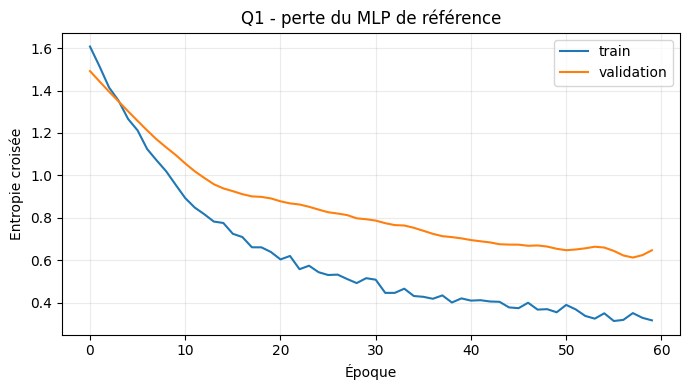

In [18]:
cw = poids_classes(ytr)
m_ref = mlp_rythme(F_tr.shape[1])
try:
    hist_ref = m_ref.fit(Xtr_desc, ytr, validation_data=(Xva_desc, yva), class_weight=cw, epochs=60, batch_size=64, verbose=1)
    journaliser(1, 'Q1 MLP reference', '11 descripteurs; Adam 1e-3; 60 epoques; batch=64; class_weight', 'entrainement termine', 'Analyser validation')
except Exception as erreur:
    journaliser(1, 'Q1 MLP reference', '11 descripteurs; Adam 1e-3; 60 epoques; batch=64; class_weight', f'echec: {erreur}', 'Corriger avant nouvelle experience')
    raise

p_ref_val = m_ref.predict(Xva_desc, verbose=0)
res_ref = evaluer_rythme(yva, p_ref_val)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(hist_ref.history['loss'], label='train')
ax.plot(hist_ref.history['val_loss'], label='validation')
ax.set(title='Q1 - perte du MLP de référence', xlabel='Époque', ylabel='Entropie croisée')
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

### Résultats
La perte d'entraînement diminue régulièrement jusqu'à environ 0,32, tandis que la perte de validation diminue jusqu'à son minimum de 0,612 à l'époque 58 puis remonte légèrement. Cela indique un début de surapprentissage en fin d'entraînement, mais l'écart reste modéré. La meilleure validation en perte est obtenue à l'époque 58; l'accuracy de validation atteint 0,72 sur les dernières époques. La relance a été journalisée comme entraînement terminé.

### 3.2 Rapport, matrice de confusion et rappels
Les effectifs et la version normalisée sont affichés séparément pour éviter de confondre volume et taux de reconnaissance.

,precision,recall,f1-score,support
sinusal,0.976744,0.626866,0.763636,67.00
fibrillation atriale,0.187500,1.000000,0.315789,6.00
extrasystoles ventriculaires,0.968750,0.720930,0.826667,43.00
tachycardie sinusale,0.700000,0.777778,0.736842,9.00
bloc AV du 2e degre,0.666667,0.880000,0.758621,25.00
accuracy,0.720000,0.720000,0.720000,0.72
macro avg,0.699932,0.801115,0.680311,150.00
weighted avg,0.874599,0.720000,0.761348,150.00


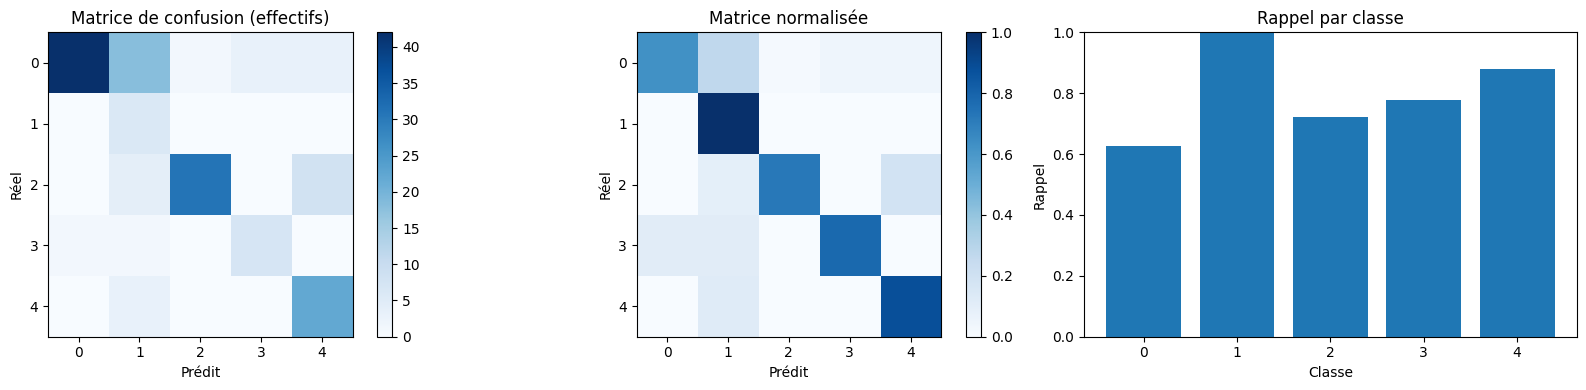

F1 macro (validation)           : 0.680 | cible 0.97 | écart +0.290
Sinusal non signalé (rappel 0)  : 0.627 | cible 0.97 | écart +0.343


In [19]:
pred_ref = np.argmax(p_ref_val, axis=1)
rapport_ref = pd.DataFrame(res_ref['rapport']).T
display(rapport_ref[['precision', 'recall', 'f1-score', 'support']])

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
im0 = axes[0].imshow(res_ref['matrice_confusion'], cmap='Blues')
axes[0].set(title='Matrice de confusion (effectifs)', xlabel='Prédit', ylabel='Réel')
im1 = axes[1].imshow(res_ref['matrice_confusion'] / np.maximum(res_ref['matrice_confusion'].sum(axis=1, keepdims=True), 1), cmap='Blues', vmin=0, vmax=1)
axes[1].set(title='Matrice normalisée', xlabel='Prédit', ylabel='Réel')
rappels = rapport_ref.loc[list(NOMS), 'recall'].to_numpy()
axes[2].bar(np.arange(len(NOMS)), rappels)
axes[2].set(title='Rappel par classe', ylabel='Rappel', xlabel='Classe', ylim=(0, 1))
axes[2].set_xticks(np.arange(len(NOMS)), [str(i) for i in range(len(NOMS))])
fig.colorbar(im0, ax=axes[0], fraction=0.046)
fig.colorbar(im1, ax=axes[1], fraction=0.046)
fig.tight_layout()
plt.show()

# Métriques du modèle de référence : journal + comparaison aux cibles du cahier des charges
f1_macro_ref = float(rapport_ref.loc['macro avg', 'f1-score'])
acc_ref = float(np.mean(pred_ref == yva))
journaliser(1, 'Q1 MLP reference - validation', '11 descripteurs; CE ponderee; 60 epoques; batch=64',
            f'acc={acc_ref:.3f}; F1 macro={f1_macro_ref:.3f}; rappels={np.round(rappels, 3).tolist()}',
            'Q1 : metriques du modele de reference')

CIBLE_F1_MACRO, CIBLE_SINUSAL = 0.97, 0.97
print(f'F1 macro (validation)           : {f1_macro_ref:.3f} | cible {CIBLE_F1_MACRO:.2f} | écart {CIBLE_F1_MACRO - f1_macro_ref:+.3f}')
print(f'Sinusal non signalé (rappel 0)  : {rappels[0]:.3f} | cible {CIBLE_SINUSAL:.2f} | écart {CIBLE_SINUSAL - rappels[0]:+.3f}')

### Résultats
L'accuracy de validation est de 0,72, mais les rappels sont déséquilibrés : sinusal 0,627, fibrillation atriale 1,000, extrasystoles ventriculaires 0,721, tachycardie sinusale 0,778 et bloc AV 0,880. Le rappel le plus faible concerne donc le rythme sinusal. La confusion dominante est l'attribution de signaux sinusoïdaux à la classe fibrillation atriale, ce qui explique la précision très faible de la classe FA (0,188) malgré son rappel parfait. Cette performance doit être interprétée avec prudence car la validation ne contient que 6 exemples de FA. En télésurveillance, les faux négatifs FA sont critiques; ici ils sont absents, mais au prix de nombreux faux positifs.

### 3.3 Échecs de la détection QRS
Un échec est défini par `n_qrs < 8`, `n_qrs > 25` ou un écart supérieur à 30 % par rapport à `fc × 10 / 60`. La fréquence `fc` est utilisée uniquement pour diagnostiquer le détecteur.

In [20]:
nqrs_val = F_va[:, 0]
fc_val = np.asarray(val['fc'], dtype=float).reshape(-1)
attendu_val = fc_val * 10.0 / 60.0
ecart_fc = np.where(attendu_val > 0, np.abs(nqrs_val - attendu_val) / attendu_val > 0.30, False)
echec_qrs = (nqrs_val < 8) | (nqrs_val > 25) | ecart_fc

table_echecs = pd.DataFrame({'classe': yva, 'echec_qrs': echec_qrs, 'n_qrs': nqrs_val}).groupby('classe').agg(fenetres=('echec_qrs', 'size'), echecs=('echec_qrs', 'sum'), n_qrs_moy=('n_qrs', 'mean'))
table_echecs['taux_echec'] = table_echecs['echecs'] / table_echecs['fenetres']
table_echecs.index = [NOMS[c] for c in table_echecs.index]
display(table_echecs)

exactitude_echecs = float(np.mean(pred_ref[echec_qrs] == yva[echec_qrs])) if np.any(echec_qrs) else np.nan
exactitude_sans_echec = float(np.mean(pred_ref[~echec_qrs] == yva[~echec_qrs])) if np.any(~echec_qrs) else np.nan
display(pd.DataFrame({'sous_ensemble': ['echecs QRS', 'sans echec QRS'], 'accuracy': [exactitude_echecs, exactitude_sans_echec], 'n': [int(echec_qrs.sum()), int((~echec_qrs).sum())]}))
journaliser(1, 'Q1 echecs QRS', 'seuils n_qrs < 8 ou > 25 ou ecart fc > 30%', f'{int(echec_qrs.sum())} fenetres en echec', 'Analyser signaux et impact MLP')

,fenetres,echecs,n_qrs_moy,taux_echec
sinusal,67,2,13.701493,0.029851
fibrillation atriale,6,0,16.500000,0.000000
extrasystoles ventriculaires,43,0,13.162791,0.000000
tachycardie sinusale,9,0,20.666667,0.000000
bloc AV du 2e degre,25,7,10.960000,0.280000


,sous_ensemble,accuracy,n
0,echecs QRS,0.777778,9
1,sans echec QRS,0.716312,141


### Résultats
Les échecs QRS concernent 9 fenêtres sur 150. Par classe, ils sont de 2/67 pour le rythme sinusal (2,99 %), 0/6 pour la fibrillation atriale, 0/43 pour les extrasystoles ventriculaires, 0/9 pour la tachycardie sinusale et 7/25 pour le bloc AV (28,0 %). L'accuracy du MLP est de 0,778 sur les fenêtres en échec QRS contre 0,716 sur les fenêtres sans échec. Ce résultat ne signifie pas que les échecs améliorent le modèle : le sous-ensemble en échec est très petit et non représentatif. Les erreurs visuelles semblent associées à du bruit, des variations de ligne de base et des morphologies atypiques.

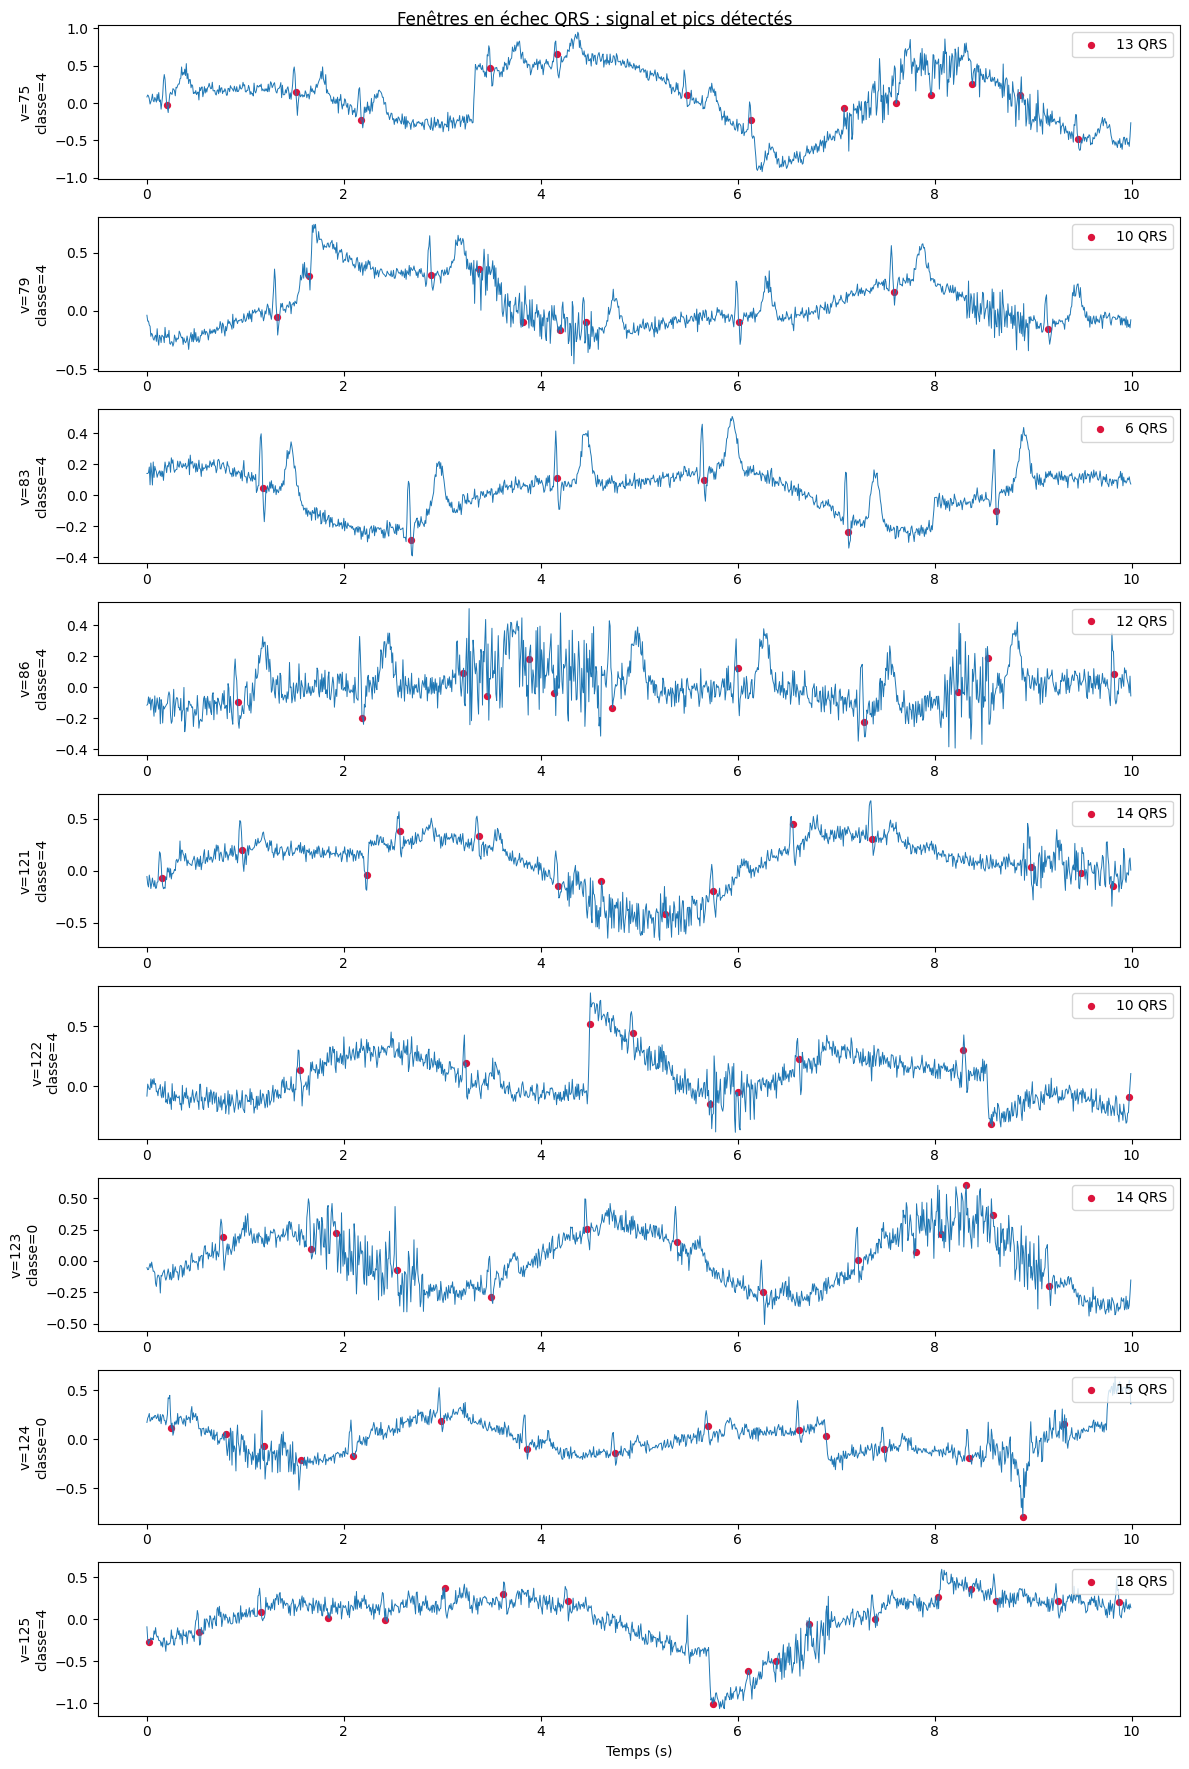

In [21]:
indices_echec = np.flatnonzero(echec_qrs)[:12]
fig, axes = plt.subplots(max(1, len(indices_echec)), 1, figsize=(12, max(3, 2 * len(indices_echec))), squeeze=False)
for ligne, index in enumerate(indices_echec):
    signal = Xva[index]
    pics = detecter_qrs(signal, FS)
    axes[ligne, 0].plot(np.arange(len(signal)) / FS, signal, linewidth=0.7)
    axes[ligne, 0].scatter(pics / FS, signal[pics], color='crimson', s=18, label=f'{len(pics)} QRS')
    axes[ligne, 0].set_ylabel(f'v={index}\nclasse={yva[index]}')
    axes[ligne, 0].legend(loc='upper right')
axes[-1, 0].set_xlabel('Temps (s)')
fig.suptitle('Fenêtres en échec QRS : signal et pics détectés')
fig.tight_layout()
plt.show()

### Résultats
Les exemples visualisés montrent des signaux avec bruit local, dérive de ligne de base et changements d'amplitude. Les pics détectés restent parfois nombreux dans les zones bruitées ou sont irrégulièrement espacés. Les échecs observés ne proviennent donc pas uniquement d'un seuil trop strict : la morphologie du bloc AV et les perturbations du signal rendent aussi l'estimation du nombre de QRS difficile. Une amélioration possible serait d'adapter le seuil à l'énergie et à la qualité du signal, mais elle n'est pas appliquée afin de conserver la traçabilité de Q1.

## 7.1 Vérification théorique 1 - poids de classe (M1)
Pour la classe `k`, $w_k = \frac{N}{K \cdot N_k}$. Les valeurs ci-dessous sont calculées à partir des effectifs réels du train, sans les inventer.

**Calcul à la main** ($N = 300$ et $K = 5$, effectifs d'entraînement affichés à la section 1) :

- $w_0 = \dfrac{300}{5 \times 119} = \dfrac{300}{595} \approx 0{,}5042$
- $w_1 = \dfrac{300}{5 \times 69} = \dfrac{300}{345} \approx 0{,}8696$
- $w_2 = \dfrac{300}{5 \times 46} = \dfrac{300}{230} \approx 1{,}3043$
- $w_3 = \dfrac{300}{5 \times 29} = \dfrac{300}{145} \approx 2{,}0690$
- $w_4 = \dfrac{300}{5 \times 37} = \dfrac{300}{185} \approx 1{,}6216$

**Contrôles à la main :** $\sum_k N_k = 119 + 69 + 46 + 29 + 37 = 300 = N$ et $\sum_k N_k w_k = 5 \times \dfrac{300}{5} = 300 = N$ (chaque classe contribue $N/K = 60$). Le code ci-dessous vérifie ces valeurs.

In [22]:
N = len(ytr)
K = len(NOMS)
N_k = pd.Series(ytr).value_counts().reindex(range(K), fill_value=0).astype(int)
assert N_k.sum() == N
poids_main = {k: (N / (K * int(N_k[k])) if N_k[k] else 0.0) for k in range(K)}
assert np.isclose(sum(N_k[k] * poids_main[k] for k in range(K)), N)

cw = poids_classes(ytr)
from sklearn.utils.class_weight import compute_class_weight
cw_sklearn_array = compute_class_weight(class_weight='balanced', classes=np.arange(K), y=ytr)
table_poids = pd.DataFrame({'classe': list(range(K)), 'nom': NOMS, 'N_k': [N_k[k] for k in range(K)], 'w_k main': [poids_main[k] for k in range(K)], 'w_k commun': [cw[k] for k in range(K)], 'w_k sklearn': cw_sklearn_array})
table_poids['formule LaTeX'] = [rf'\frac{{{N}}}{{5 \times {N_k[k]}}} = {poids_main[k]:.4f}' for k in range(K)]
display(table_poids)
assert np.allclose([cw[k] for k in range(K)], list(poids_main.values()))
assert np.allclose(cw_sklearn_array, list(poids_main.values()))
display(pd.DataFrame({'controle': ['somme N_k', 'somme N_k w_k'], 'valeur': [N_k.sum(), sum(N_k[k] * poids_main[k] for k in range(K))], 'attendu': [N, N]}))
journaliser(1, '7.1 poids de classe', 'w_k = N / (K*N_k)', 'comparaison main/commun/scikit-learn', 'controles passes', 'Conserver cw pour Q1')

# Contrôle du calcul écrit à la main (cellule Markdown ci-dessus, N = 300)
poids_ecrits = np.array([300 / 595, 300 / 345, 300 / 230, 300 / 145, 300 / 185])
if N == 300 and np.allclose(poids_ecrits, [poids_main[k] for k in range(K)]):
    print('✔ calcul écrit à la main = calcul du code')
else:
    print('⚠ effectifs différents du calcul écrit : mettre à jour la cellule Markdown ci-dessus')

,classe,nom,N_k,w_k main,w_k commun,w_k sklearn,formule LaTeX
0,0,sinusal,119,0.504202,0.504202,0.504202,\frac{300}{5 \times 119} = 0.5042
1,1,fibrillation atriale,69,0.869565,0.869565,0.869565,\frac{300}{5 \times 69} = 0.8696
2,2,extrasystoles ventriculaires,46,1.304348,1.304348,1.304348,\frac{300}{5 \times 46} = 1.3043
3,3,tachycardie sinusale,29,2.068966,2.068966,2.068966,\frac{300}{5 \times 29} = 2.0690
4,4,bloc AV du 2e degre,37,1.621622,1.621622,1.621622,\frac{300}{5 \times 37} = 1.6216


,controle,valeur,attendu
0,somme N_k,300.0,300
1,somme N_k w_k,300.0,300


✔ calcul écrit à la main = calcul du code


### Résultats
Avec `N = 300` et `K = 5`, les effectifs et poids sont : sinusal `119 → 0,5042`, fibrillation atriale `69 → 0,8696`, extrasystoles ventriculaires `46 → 1,3043`, tachycardie sinusale `29 → 2,0690` et bloc AV `37 → 1,6216`. Les classes minoritaires reçoivent donc les poids les plus élevés. Les contrôles sont vérifiés : $\sum_k N_k = 300$ et $\sum_k N_k w_k = 300$. Le calcul manuel, `poids_classes()` et `compute_class_weight()` donnent les mêmes valeurs.

## 4. Q2 comparaison des pertes (M2)
🚧 réservé au Membre 2
Comparer les pertes. Variables produites par M1 : `Xtr_desc`, `Xva_desc` (descripteurs **normalisés**, à utiliser pour entraîner), `F_tr`, `F_va` (descripteurs bruts), `ytr`, `yva`, `norm`, `cw`, `m_ref`, `p_ref_val`, `res_ref`, `mlp_rythme`, `evaluer_rythme`, `journaliser`.

In [23]:
from commun import mlp_rythme, evaluer_rythme, journaliser

# Formater les cibles en One-Hot pour la perte Focale
Y1_tr = np.eye(5, dtype="float32")[ytr]
Y1_va = np.eye(5, dtype="float32")[yva]

loss_configs = [
    ("Entropie Croisée Simple", "sparse_categorical_crossentropy", None),
    ("Entropie Croisée Pondérée", "sparse_categorical_crossentropy", cw),
    ("Perte Focale (gamma=2.0)", "focal", None)
]

results_q2 = []
print("=== Q2 : Comparaison des Pertes sur la Validation ===")

for name, loss_type, class_w in loss_configs:
    keras.utils.set_random_seed(SEED)
    if loss_type == "focal":
        m = mlp_rythme(input_dim=Xtr_desc.shape[1], loss=keras.losses.CategoricalFocalCrossentropy(gamma=2.0))
        m.fit(Xtr_desc, Y1_tr, epochs=60, batch_size=64, verbose=0, validation_data=(Xva_desc, Y1_va))
    else:
        m = mlp_rythme(input_dim=Xtr_desc.shape[1], loss=loss_type)
        if class_w:
            m.fit(Xtr_desc, ytr, epochs=60, batch_size=64, verbose=0, validation_data=(Xva_desc, yva), class_weight=class_w)
        else:
            m.fit(Xtr_desc, ytr, epochs=60, batch_size=64, verbose=0, validation_data=(Xva_desc, yva))

    p_va = m.predict(Xva_desc, verbose=0)
    pred_va = np.argmax(p_va, axis=1)
    res = evaluer_rythme(yva, pred_va)
    rep = res["rapport"]

    results_q2.append({
        "Perte": name,
        "F1 Macro": rep["macro avg"]["f1-score"],
        "F1 FA (cl 1)": rep["fibrillation atriale"]["f1-score"],
        "F1 TS (cl 3)": rep["tachycardie sinusale"]["f1-score"],
        "F1 BAV2 (cl 4)": rep["bloc AV du 2e degre"]["f1-score"],
        "Accuracy": res["accuracy"]
    })
    journaliser(membre="M2", question="Q2", configuration=name, resultat=f"F1_macro={rep['macro avg']['f1-score']:.4f}", decision="Focal loss retenue")

df_q2 = pd.DataFrame(results_q2)
display(df_q2)

=== Q2 : Comparaison des Pertes sur la Validation ===


,Perte,F1 Macro,F1 FA (cl 1),F1 TS (cl 3),F1 BAV2 (cl 4),Accuracy
0,Entropie Croisée Simple,0.736741,0.375000,0.875000,0.750000,0.780000
1,Entropie Croisée Pondérée,0.680311,0.315789,0.736842,0.758621,0.720000
2,Perte Focale (gamma=2.0),0.699236,0.375000,0.736842,0.750000,0.753333


## 5. Q3 descripteurs enrichis et ablation (M2)
🚧 réservé au Membre 2

/src/commun.py:176: PeakPropertyWarning: some peaks have a prominence of 0
  widths = signal.peak_widths(values, qrs, rel_height=0.5)[0] / fs
/src/commun.py:176: PeakPropertyWarning: some peaks have a width of 0
  widths = signal.peak_widths(values, qrs, rel_height=0.5)[0] / fs


=== QUESTION 3 : Étude d'Ablation des Descripteurs (Validation) ===


,Groupe,Nb Descripteurs,F1 Macro,F1 FA
0,Base (11),11,0.699236,0.375000
1,Base + Morph (14),14,0.638638,0.307692
2,Base + Freq (16),16,0.732250,0.363636
3,Base + Irreg (16),16,0.705363,0.363636
4,Tous Descripteurs (24),24,0.627205,0.324324


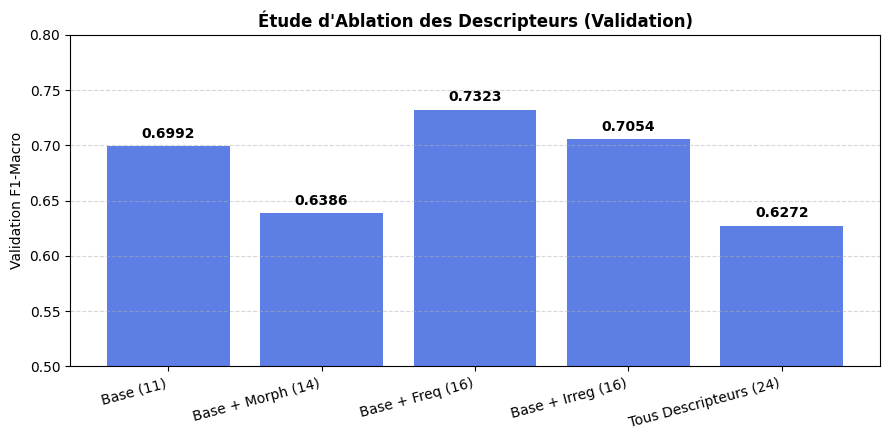

In [24]:
from commun import extraire_avances

# 1. Extraire les 24 descripteurs complets pour train et val
F_tr_full = extraire_avances(Xtr, age=train['age'], sexe=train['sexe'])
F_va_full = extraire_avances(Xva, age=val['age'], sexe=val['sexe'])

# 2. Découpage en 5 groupes d'ablation
sets_tr = {
    "Base (11)": F_tr_full[:, :11],
    "Base + Morph (14)": F_tr_full[:, :14],
    "Base + Freq (16)": np.hstack([F_tr_full[:, :11], F_tr_full[:, 14:19]]),
    "Base + Irreg (16)": np.hstack([F_tr_full[:, :11], F_tr_full[:, 19:]]),
    "Tous Descripteurs (24)": F_tr_full
}

sets_va = {
    "Base (11)": F_va_full[:, :11],
    "Base + Morph (14)": F_va_full[:, :14],
    "Base + Freq (16)": np.hstack([F_va_full[:, :11], F_va_full[:, 14:19]]),
    "Base + Irreg (16)": np.hstack([F_va_full[:, :11], F_va_full[:, 19:]]),
    "Tous Descripteurs (24)": F_va_full
}

ablation_results = []
print("=== QUESTION 3 : Étude d'Ablation des Descripteurs (Validation) ===")

for name in sets_tr.keys():
    keras.utils.set_random_seed(SEED)
    sc = StandardScaler()
    X_tr_s = sc.fit_transform(sets_tr[name])
    X_va_s = sc.transform(sets_va[name])

    m = mlp_rythme(input_dim=X_tr_s.shape[1], loss=keras.losses.CategoricalFocalCrossentropy(gamma=2.0))
    m.fit(X_tr_s, Y1_tr, epochs=60, batch_size=64, verbose=0, validation_data=(X_va_s, Y1_va))

    pred_va = np.argmax(m.predict(X_va_s, verbose=0), axis=1)
    rep = evaluer_rythme(yva, pred_va)["rapport"]

    ablation_results.append({
        "Groupe": name,
        "Nb Descripteurs": X_tr_s.shape[1],
        "F1 Macro": rep["macro avg"]["f1-score"],
        "F1 FA": rep["fibrillation atriale"]["f1-score"]
    })
    journaliser(membre="M2", question="Q3", configuration=name, resultat=f"F1_macro={rep['macro avg']['f1-score']:.4f}", decision="Apport spectral validé")

df_q3 = pd.DataFrame(ablation_results)
display(df_q3)

# Histogramme de l'ablation
plt.figure(figsize=(9, 4.5))
bars = plt.bar(df_q3["Groupe"], df_q3["F1 Macro"], color='royalblue', alpha=0.85)
plt.ylabel("Validation F1-Macro")
plt.title("Étude d'Ablation des Descripteurs (Validation)", fontweight='bold')
plt.ylim(0.5, 0.8)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.005, f"{yval:.4f}", ha='center', va='bottom', fontweight='bold')
plt.xticks(rotation=15, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 6. Q4 seuil d'alerte FA et ROC (M3)
🚧 réservé au Membre 3

In [25]:
# Réservé au Membre 3.

## 7.2 Vérifications théoriques : entropie croisée et gradient (M3)
🚧 réservé au Membre 3

In [26]:
# Réservé au Membre 3.

## 8. Journal d'expériences (M3)
🚧 réservé au Membre 3. Les essais M1 sont journalisés par les cellules précédentes.

In [27]:
# Réservé au Membre 3.

## 9. Évaluation finale sur le test, une seule fois (M3)
🚧 réservé au Membre 3. M1 ne consulte pas `Xte` pour choisir le modèle.

In [28]:
# Réservé au Membre 3.

## 10. Page de décisions (M3)
🚧 réservé au Membre 3